In [11]:
# Import dependencies

import os
import wandb
import wandb_workspaces.workspaces as ws
import wandb_workspaces.reports.v2 as wr # We use the Reports API for adding panels


In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
WANDB_API_KEY = "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"
ENTITY = "kirill456z"
PROJECT = "physics4llm"

if WANDB_API_KEY:
    os.environ["WANDB_API_KEY"] = WANDB_API_KEY
if ENTITY:
    os.environ["WANDB_ENTITY"] = ENTITY

In [14]:
import wandb_workspaces.reports.v2 as wr

report = wr.Report.from_url("https://wandb.ai/kirill456z/physics4llm/reports/Quickstart-Report--VmlldzoxNjE0MzE4NA")

In [15]:
report.width = "fluid"

### Training Stability

[to_matplotlib] Loaded 4 runs


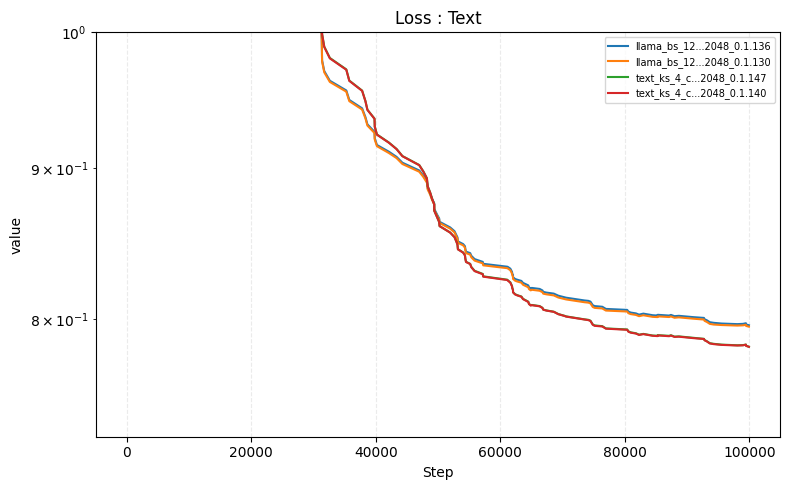

Saved: /Users/kirillzemlanskij/Workspace/PhysicsLM4/reports/plots/march09_stability_text_loss.png
[to_matplotlib] Loaded 5 runs


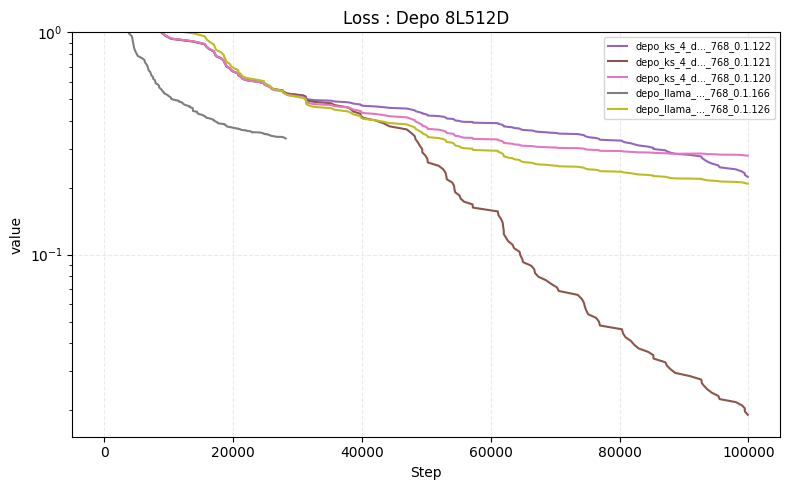

Saved: /Users/kirillzemlanskij/Workspace/PhysicsLM4/reports/plots/march09_stability_depo_8l512d_loss.png
[to_matplotlib] Loaded 2 runs


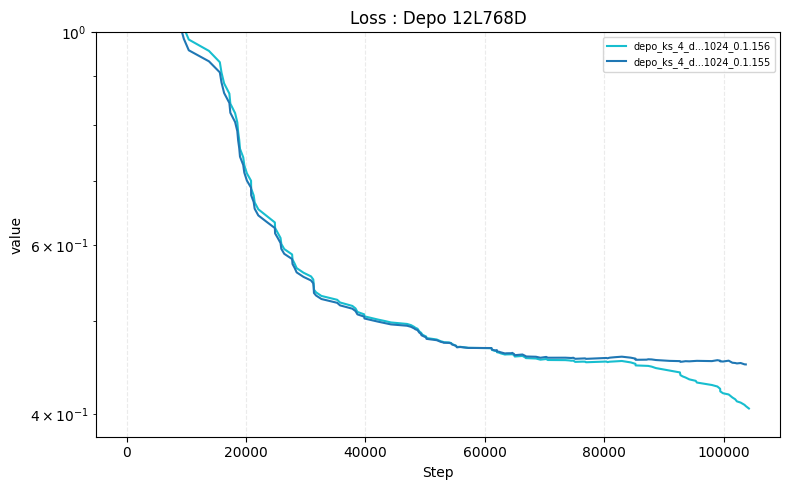

Saved: /Users/kirillzemlanskij/Workspace/PhysicsLM4/reports/plots/march09_stability_depo_12l768d_loss.png
[to_matplotlib] Loaded 2 runs


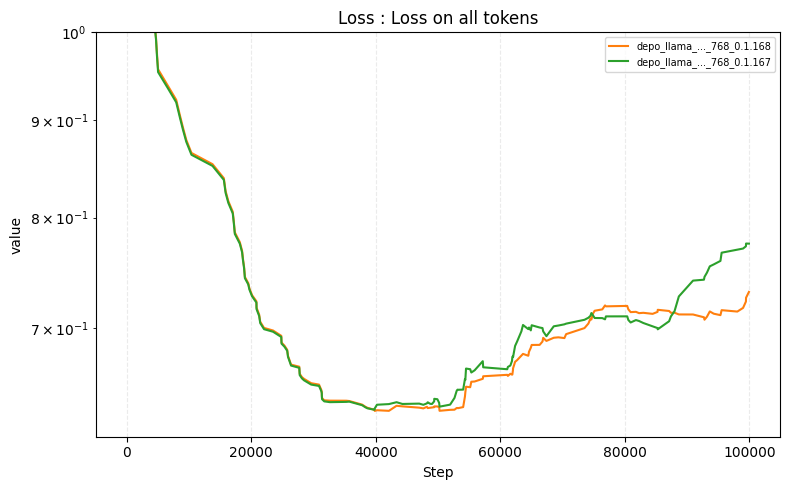

Saved: /Users/kirillzemlanskij/Workspace/PhysicsLM4/reports/plots/march09_stability_depo_all_tokens_loss.png


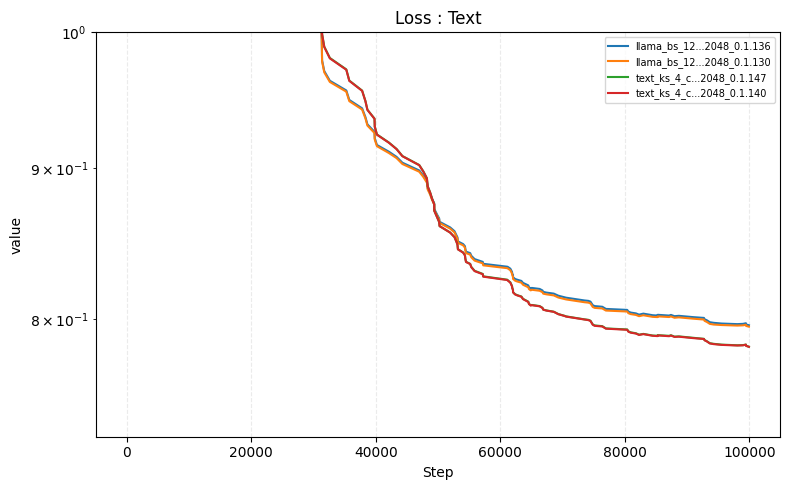

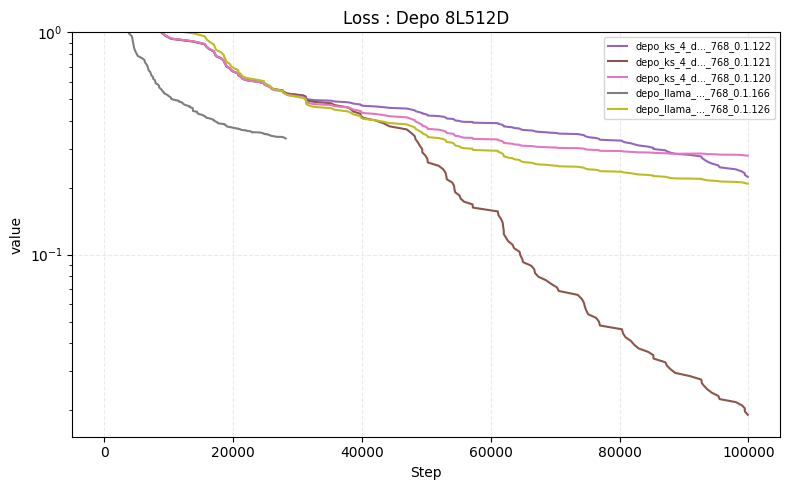

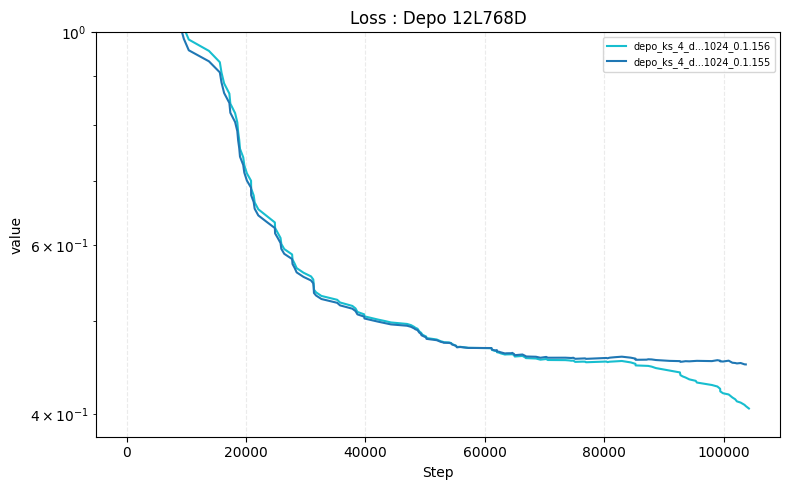

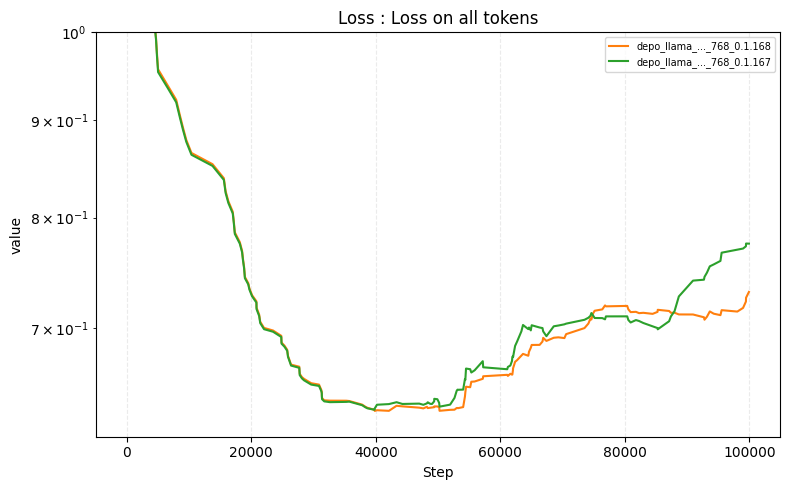

In [16]:
from plots import loss_lineplot, to_matplotlib
from runsets import RunsetsFactory

runsets_factory = RunsetsFactory(ENTITY, PROJECT)
FAST_PLOT_KWARGS = dict(api_timeout=90, max_points_per_series=150, use_scan_fallback=False)

text_run_names = [
    "text_llama_bs_128_seq_len_2048_0.1.136",
    "canon_text_0.1.130",
    "text_ks_4_const_var_sqr_init_with_residual_trainable_bs_128_seq_len_2048_0.1.147",
    "text_ks_4_const_var_sqr_init_with_residual_trainable_bs_128_seq_len_2048_0.1.140",
]
depo_run_names = [
    "depo_ks_4_default_init_with_residual_trainable_0.1.122",
    "depo_ks_4_default_init_with_residual_trainable_0.1.121",
    "depo_ks_4_default_init_with_residual_trainable_0.1.120",
    "depo_llama_8_hops_100_nodes_bs_256_seq_len_768_0.1.166",
    "llama_0.1.126"
]
depo_biger_model = [
    "depo_ks_4_default_init_with_residual_trainable_8_hops_100_nodes_bs_128_seq_len_1024_0.1.156",
    "depo_ks_4_default_init_with_residual_trainable_8_hops_100_nodes_bs_128_seq_len_1024_0.1.155"
]
depo_full_tok_train = [
    "depo_llama_8_hops_100_nodes_bs_256_seq_len_768_0.1.168",
    "depo_llama_8_hops_100_nodes_bs_256_seq_len_768_0.1.167"
]

text_runs = [runsets_factory.filter_by_run_names(text_run_names)]
depo_runs = [runsets_factory.filter_by_run_names(depo_run_names)]
depo_big_runs = [runsets_factory.filter_by_run_names(depo_biger_model)]
depo_full_tok_runs = [runsets_factory.filter_by_run_names(depo_full_tok_train)]

text_loss_plots = [loss_lineplot()]
text_loss_fig, text_loss_path = to_matplotlib(
    text_loss_plots,
    text_runs,
    num_subplots_h=1,
    num_subplots_w=1,
    h=5,
    w=8,
    output_name="march09_stability_text_loss",
    **FAST_PLOT_KWARGS,
)
print(f"Saved: {text_loss_path}")

depo_loss_plots = [loss_lineplot(title="Depo 8L512D")]
depo_loss_fig, depo_loss_path = to_matplotlib(
    depo_loss_plots,
    depo_runs,
    num_subplots_h=1,
    num_subplots_w=1,
    h=5,
    w=8,
    output_name="march09_stability_depo_8l512d_loss",
    **FAST_PLOT_KWARGS,
)
print(f"Saved: {depo_loss_path}")

depo_big_loss_plots = [loss_lineplot("Depo 12L768D")]
depo_big_loss_fig, depo_big_loss_path = to_matplotlib(
    depo_big_loss_plots,
    depo_big_runs,
    num_subplots_h=1,
    num_subplots_w=1,
    h=5,
    w=8,
    output_name="march09_stability_depo_12l768d_loss",
    **FAST_PLOT_KWARGS,
)
print(f"Saved: {depo_big_loss_path}")

depo_full_tok_loss_plots = [loss_lineplot("Loss on all tokens")]
depo_full_tok_loss_fig, depo_full_tok_loss_path = to_matplotlib(
    depo_full_tok_loss_plots,
    depo_full_tok_runs,
    num_subplots_h=1,
    num_subplots_w=1,
    h=5,
    w=8,
    output_name="march09_stability_depo_all_tokens_loss",
    **FAST_PLOT_KWARGS,
)
print(f"Saved: {depo_full_tok_loss_path}")

report.blocks = [
    wr.TableOfContents(),
    wr.H1(text="09.03"),
    wr.H2(text="Stability of training"),
    wr.P(text="Same model, same data, different model parameter seeds. Very similar dynamics on text data. Big variance on depo task."),
    # Two panel grids side by side - text runs and depo runs (each grid has its own runset)
    wr.PanelGrid(
        runsets=text_runs,
        panels=text_loss_plots,
        hide_run_sets=True,
    ),
    wr.PanelGrid(
        runsets=depo_runs,
        panels=depo_loss_plots,
        hide_run_sets=True
    ),
    wr.PanelGrid(
        runsets=depo_big_runs,
        panels=depo_big_loss_plots,
        hide_run_sets=True
    ),
    wr.PanelGrid(
        runsets=depo_full_tok_runs,
        panels=depo_full_tok_loss_plots,
        hide_run_sets=True
    )
]

march09_stability_text_loss.png: two seeds of llama vs too seeds of canon. Same model with different seeds has the same training dynamics, no variance from seeds. canon has worse performance until step 50000. Then canon overtakes llama and reaches lover loss values. (0.776 vs 0.79)

march09_stability_depo_8l512d_loss: high degree of variance in model convergence. One of the llama seeds converges much much faster than other canon seeds showcasing that the training is unreliable and is highly susseptible to random variance

march09_stability_depo_12l768d_loss: showcases variance on depo task when bigger model is trained. Two runs of the same canon model with different seeds. They diverge one of the models has relatively high loss while the other suddenly has a grokking moment and it's loss drops




### Kernel Size Ablation

[to_matplotlib] Loaded 5 runs


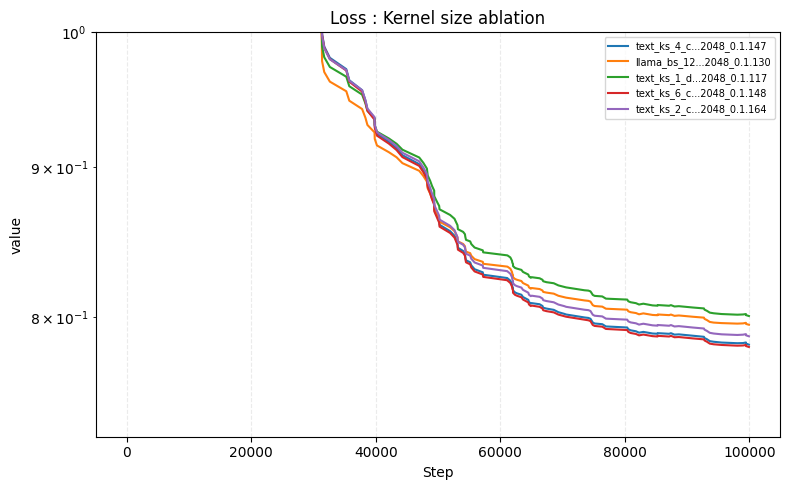

Saved: /Users/kirillzemlanskij/Workspace/PhysicsLM4/reports/plots/march09_kernel_size_ablation_loss.png


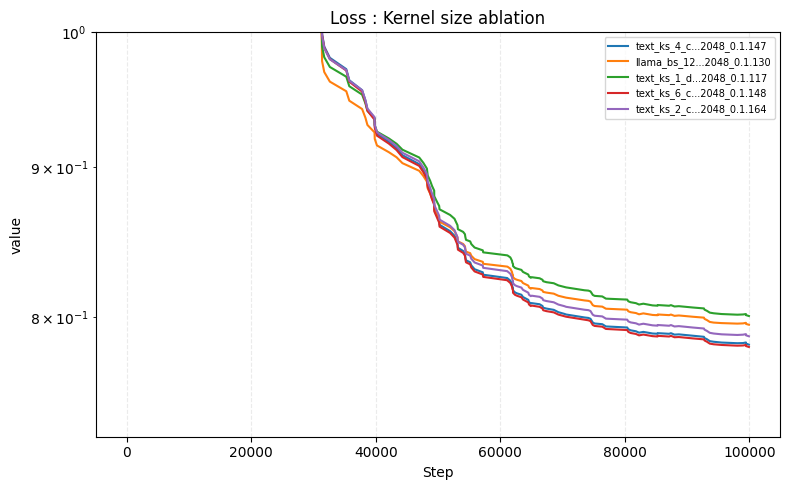

In [17]:
from plots import canon_weight_fixed_layer

runsets_factory = RunsetsFactory(ENTITY, PROJECT)

depo_ks_ablation_run_names = [
    "text_ks_4_const_var_sqr_init_with_residual_trainable_bs_128_seq_len_2048_0.1.147",
    "canon_text_0.1.130", #text_llama_bs_128_seq_len_2048_0.1.130
    "canon_text_0.1.117", #text_ks_1_default_init_with_residual_trainable_bs_128_seq_len_2048_0.1.117
    "text_ks_6_const_var_sqr_init_with_residual_trainable_bs_128_seq_len_2048_0.1.148",
    "text_ks_2_const_var_sqr_init_with_residual_trainable_bs_128_seq_len_2048_0.1.164"
]

runs = [runsets_factory.filter_by_run_names(depo_ks_ablation_run_names)] 

ks_ablation_plots = [loss_lineplot("Kernel size ablation")]
ks_ablation_fig, ks_ablation_path = to_matplotlib(
    ks_ablation_plots,
    runs,
    num_subplots_h=1,
    num_subplots_w=1,
    h=5,
    w=8,
    output_name="march09_kernel_size_ablation_loss",
    **FAST_PLOT_KWARGS,
)
print(f"Saved: {ks_ablation_path}")

report.blocks += [
    wr.H2(text='Kernel size ablation'),
    wr.P(text="ks 1 > baseline > ks 2 > ks 4 > ks 6"),
    wr.PanelGrid(
        runsets=runs,
        panels=ks_ablation_plots,
        hide_run_sets=True
    )
]


march09_kernel_size_ablation_loss: ablation of kernel sizes of canon on text modeling task ther results are : 1 is the worst then baseline, then kernel 2, 4 and 6 is the best



### Initialization ablation

[to_matplotlib] Loaded 5 runs


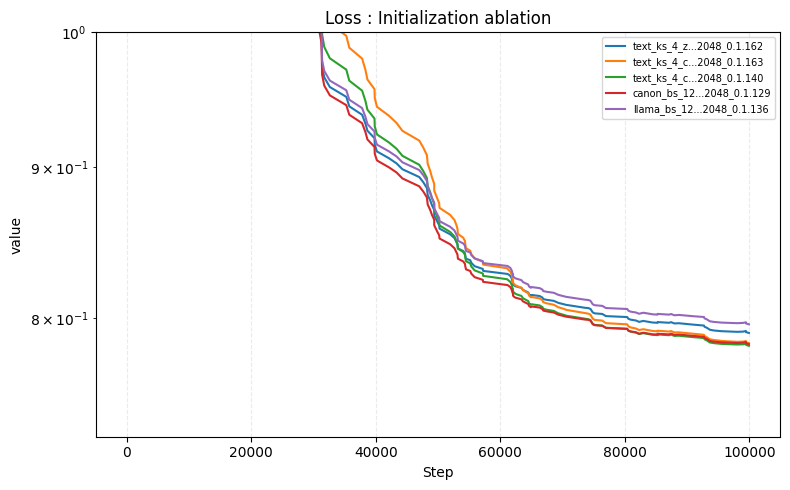

Saved: /Users/kirillzemlanskij/Workspace/PhysicsLM4/reports/plots/march09_initialization_ablation_loss.png


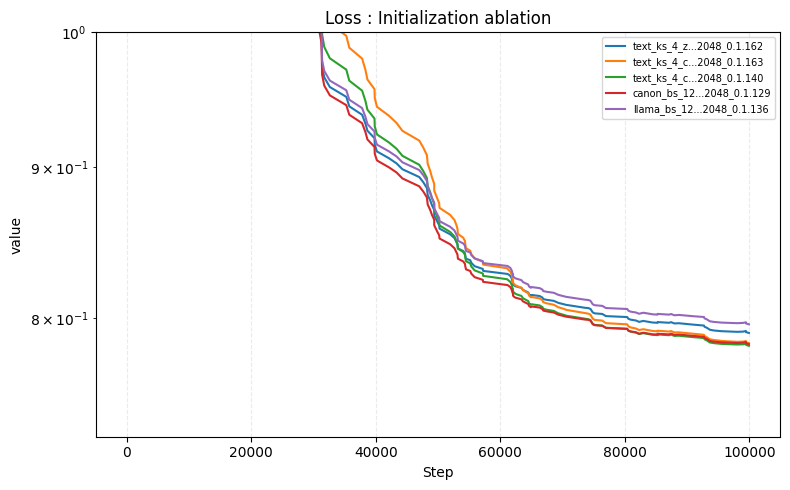

In [18]:

from plots import canon_weight_fixed_layer

runsets_factory = RunsetsFactory(ENTITY, PROJECT)

init_ablation_run_names = [
    "text_ks_4_zeros_init_with_residual_trainable_bs_128_seq_len_2048_0.1.162",
    "text_ks_4_const_var_init_with_residual_trainable_bs_128_seq_len_2048_0.1.163",
    "text_ks_4_const_var_sqr_init_with_residual_trainable_bs_128_seq_len_2048_0.1.140",
    "canon_text_0.1.129",
    "text_llama_bs_128_seq_len_2048_0.1.136"
]

runs = [runsets_factory.filter_by_run_names(init_ablation_run_names)] 

init_ablation_plots = [loss_lineplot("Initialization ablation")]
init_ablation_fig, init_ablation_path = to_matplotlib(
    init_ablation_plots,
    runs,
    num_subplots_h=1,
    num_subplots_w=1,
    h=5,
    w=8,
    output_name="march09_initialization_ablation_loss",
    **FAST_PLOT_KWARGS,
)
print(f"Saved: {init_ablation_path}")

report.blocks += [
    wr.H2(text='Initialization ablation'),
    wr.PanelGrid(
        runsets=runs,
        panels=init_ablation_plots,
        hide_run_sets=True
    )
]


march09_initialization_ablation_loss: baseline - worst (highest loss) > zero init > default init (random from -1/sqrt(kernel size) to 1 / sqrt(kernel size)) > const_var (constant 1 / sqrt(kernel_size)) > const_var_sqrt ( 1 / kernel_size)


### Training Dynamics Observations

[to_matplotlib] Loaded 2 runs


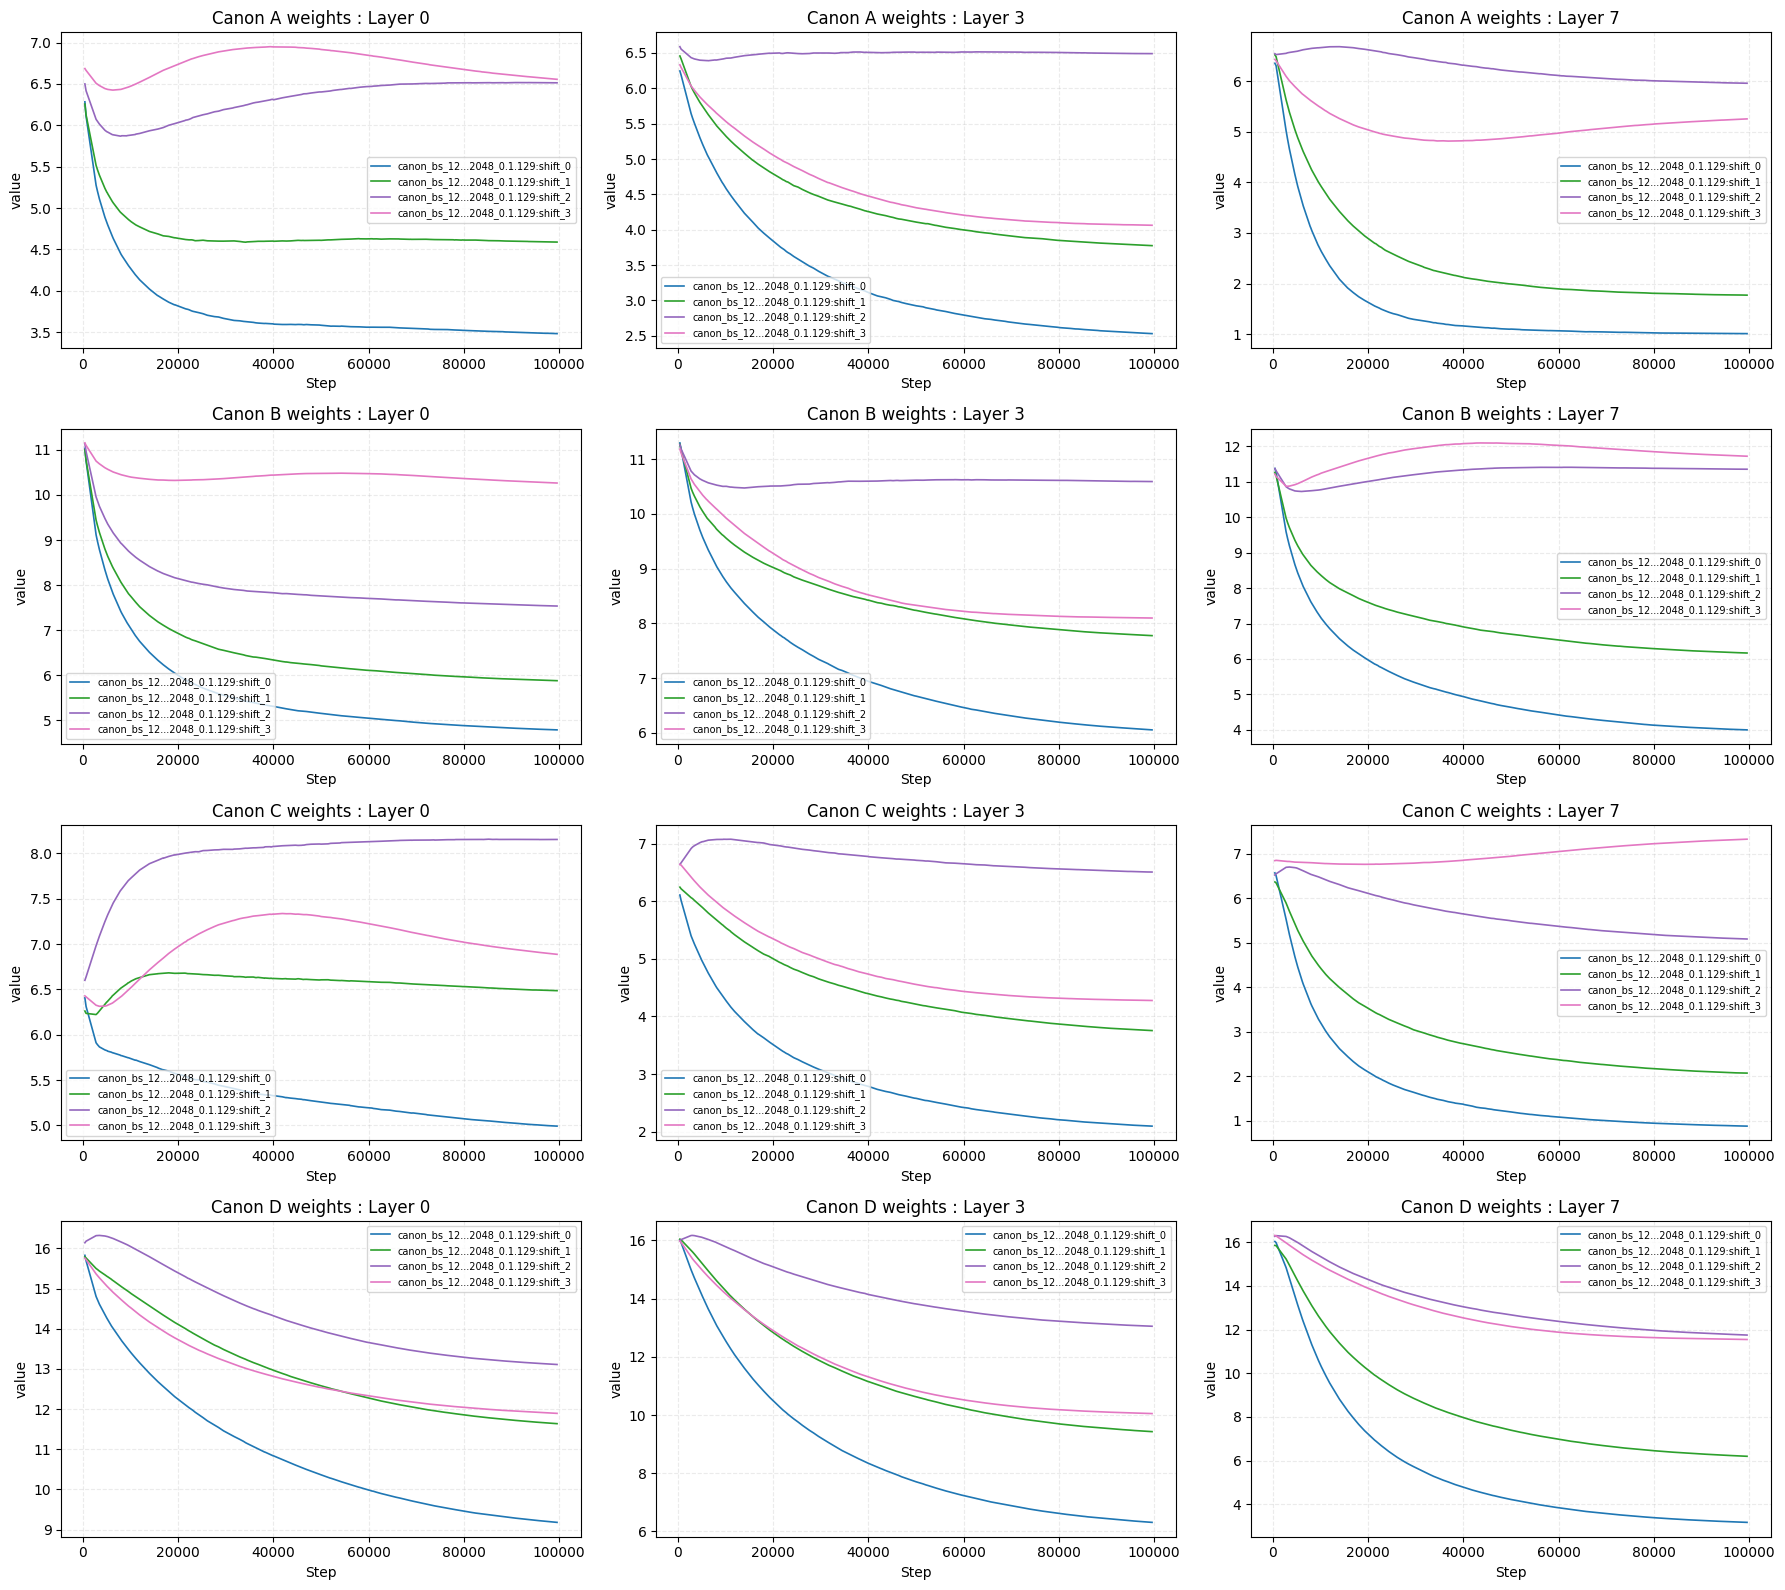

Saved: /Users/kirillzemlanskij/Workspace/PhysicsLM4/reports/plots/march09_dynamics_canon_weights_layerwise.png
[to_matplotlib] Loaded 2 runs


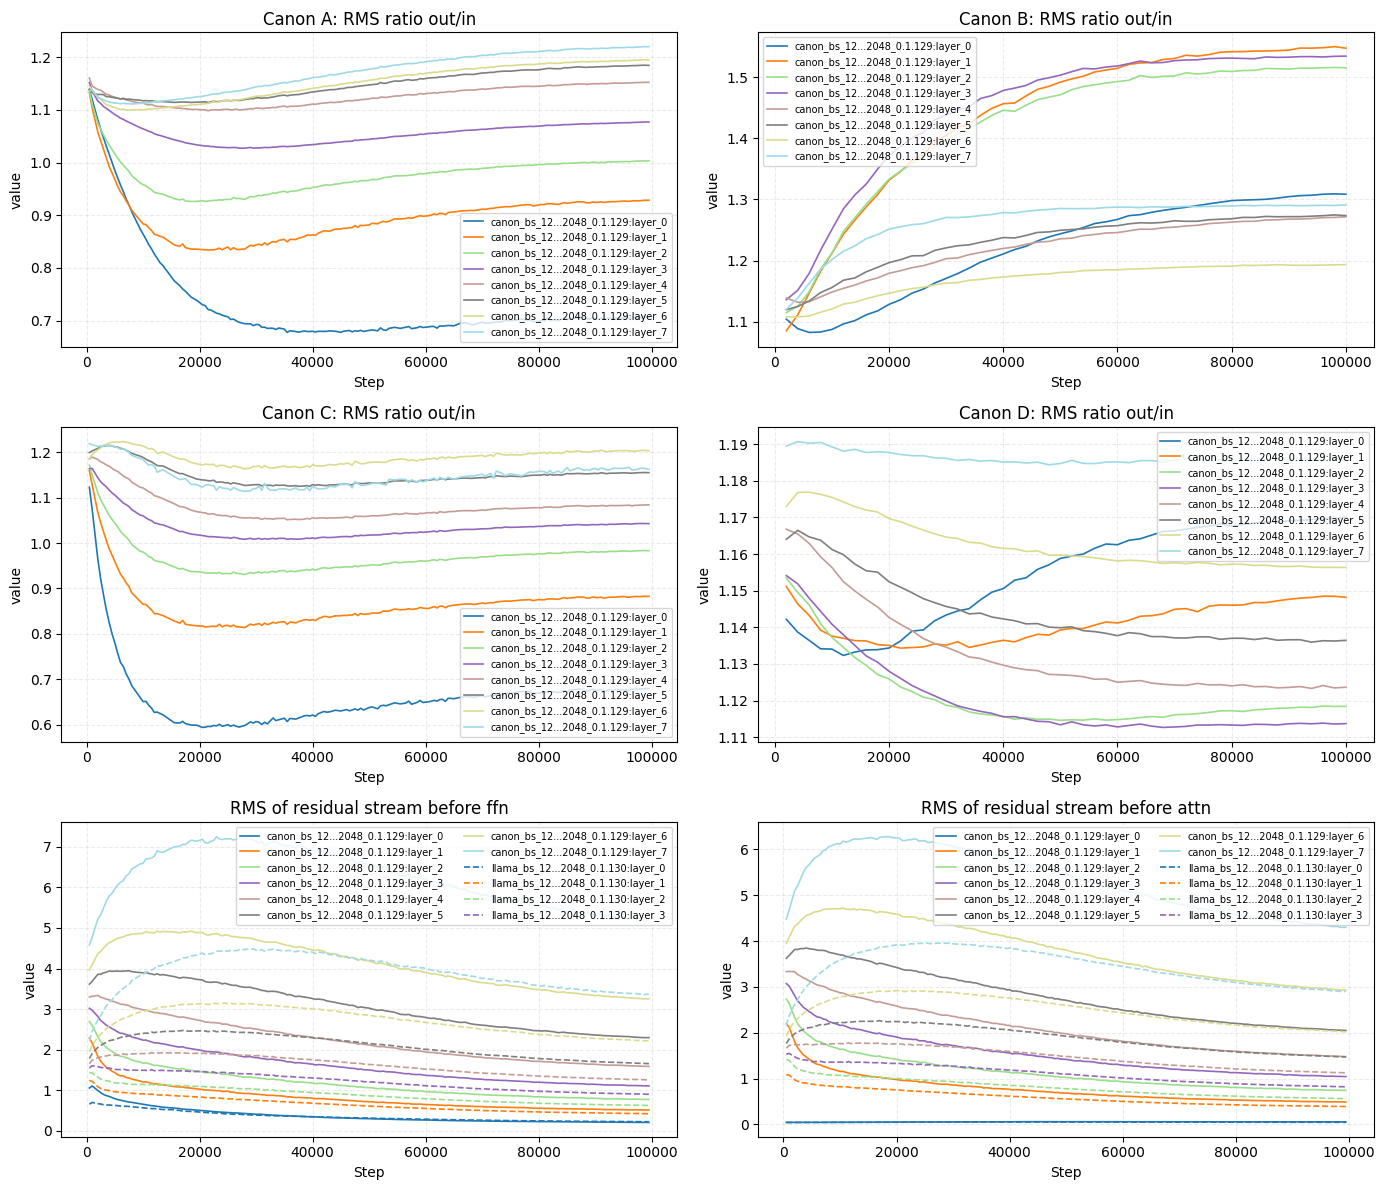

Saved: /Users/kirillzemlanskij/Workspace/PhysicsLM4/reports/plots/march09_dynamics_rms_ratio_and_residual.png
[to_matplotlib] Loaded 2 runs


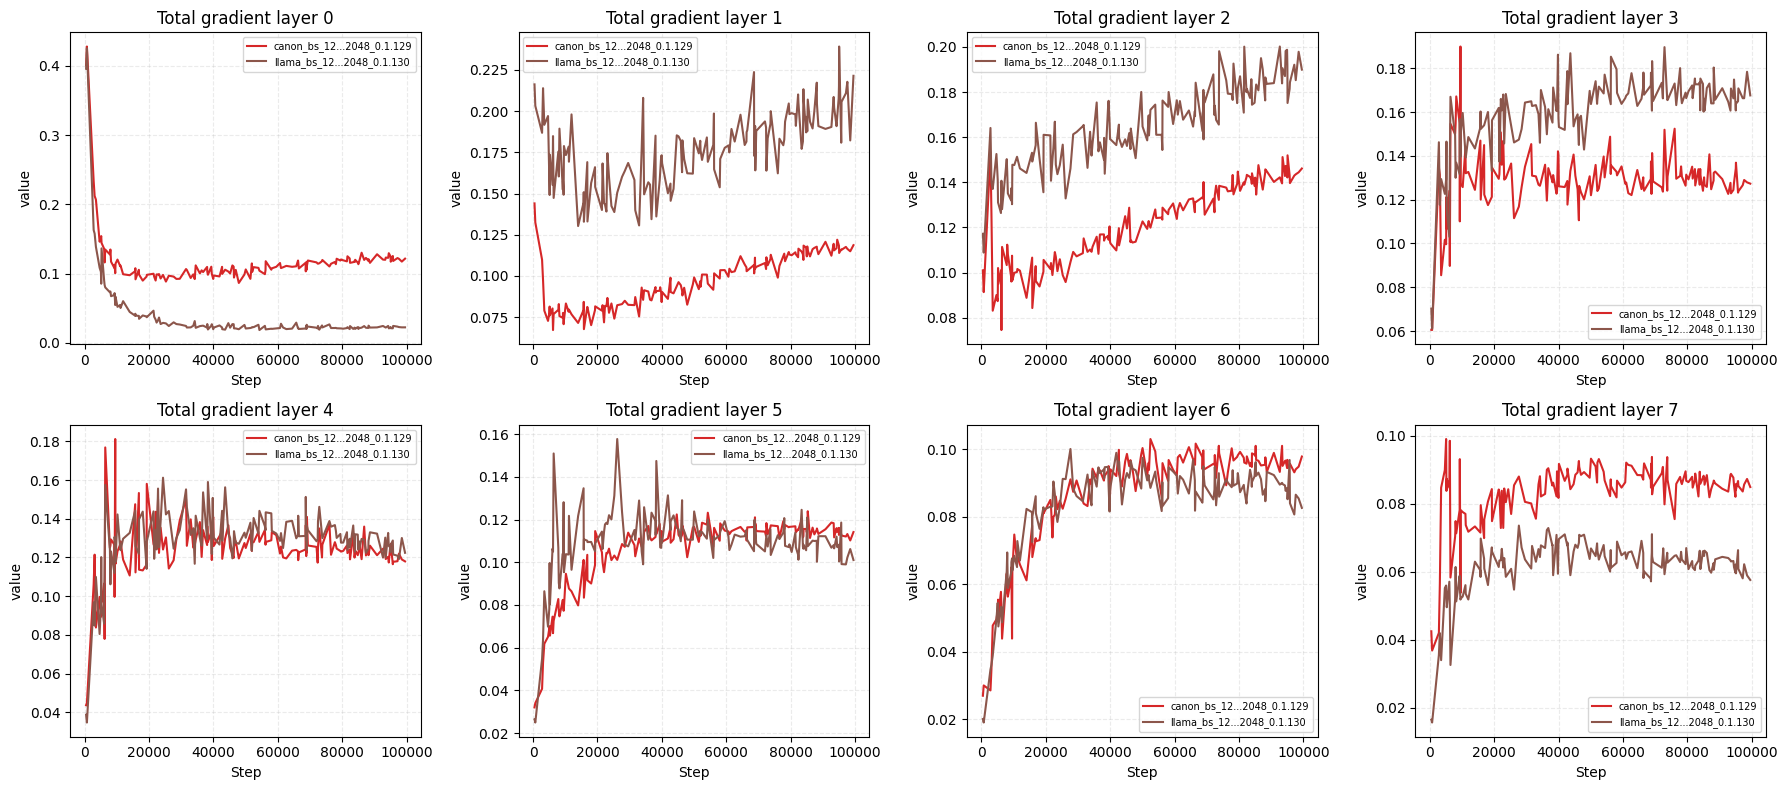

Saved: /Users/kirillzemlanskij/Workspace/PhysicsLM4/reports/plots/march09_dynamics_grad_contrib.png
[to_matplotlib] Loaded 2 runs


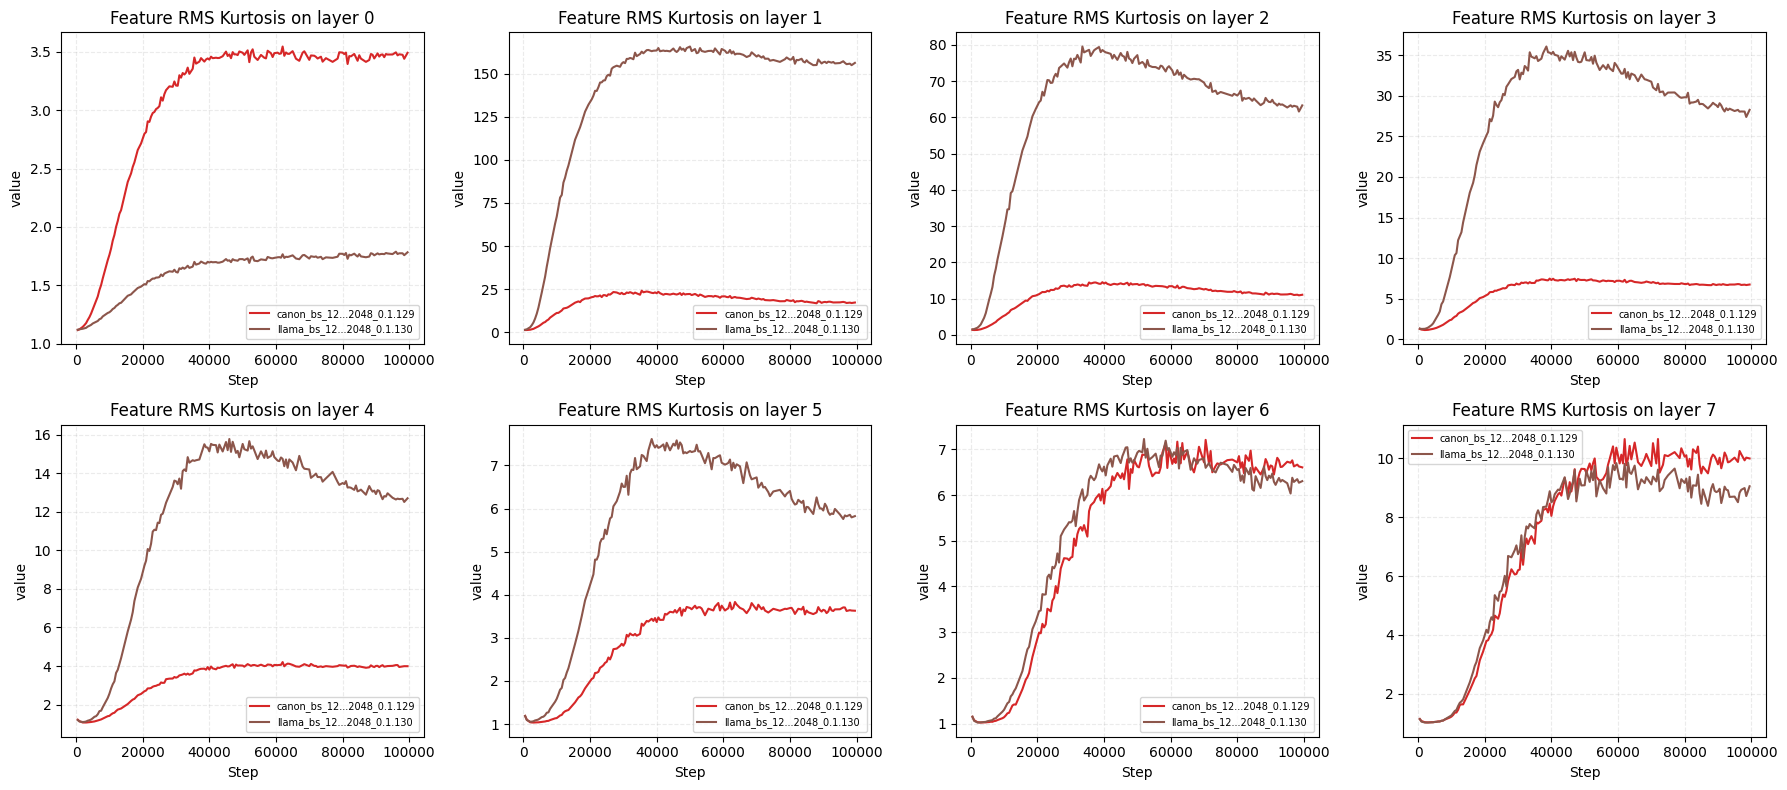

Saved: /Users/kirillzemlanskij/Workspace/PhysicsLM4/reports/plots/march09_dynamics_outlier_features_kurtosis.png
[to_matplotlib] Loaded 2 runs


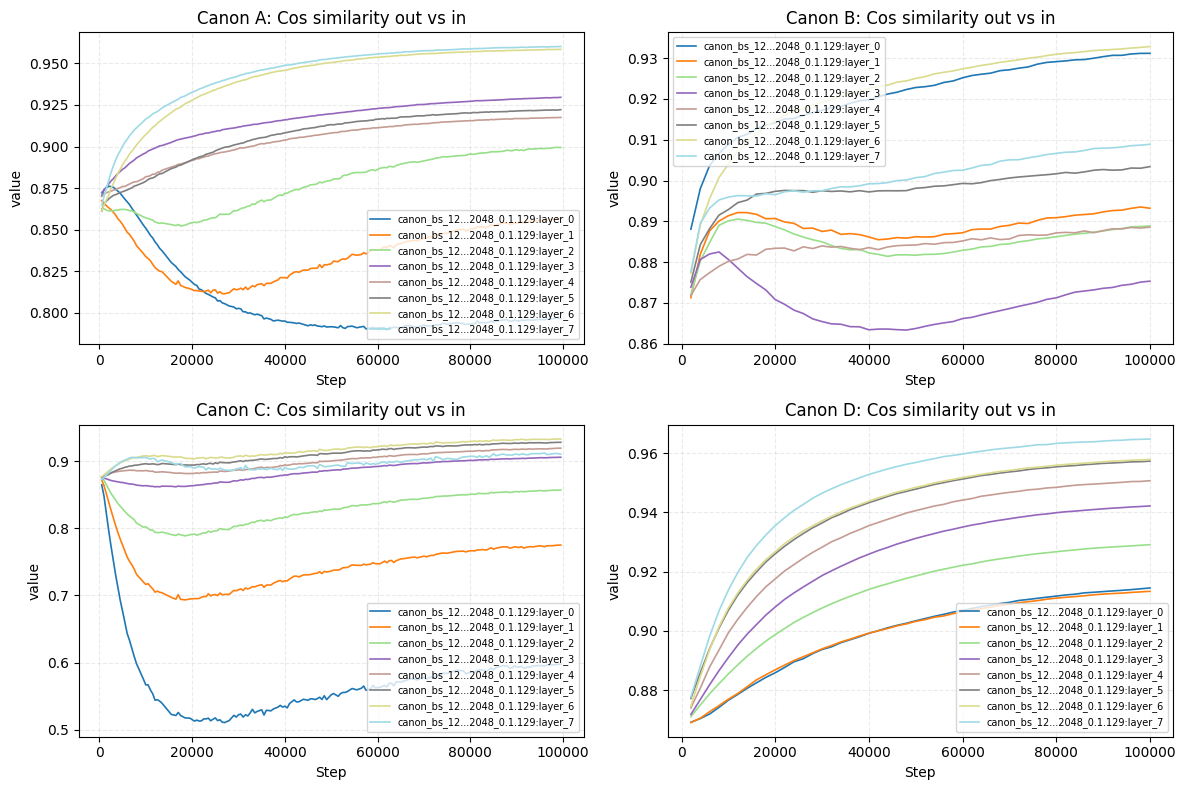

Saved: /Users/kirillzemlanskij/Workspace/PhysicsLM4/reports/plots/march09_dynamics_canon_cos_similarity.png
[to_matplotlib] Loaded 3 runs


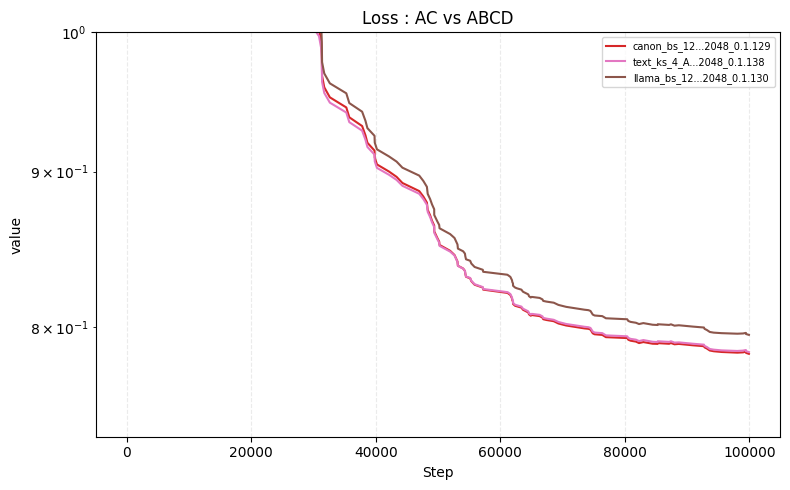

Saved: /Users/kirillzemlanskij/Workspace/PhysicsLM4/reports/plots/march09_dynamics_loss_ac_vs_abcd.png


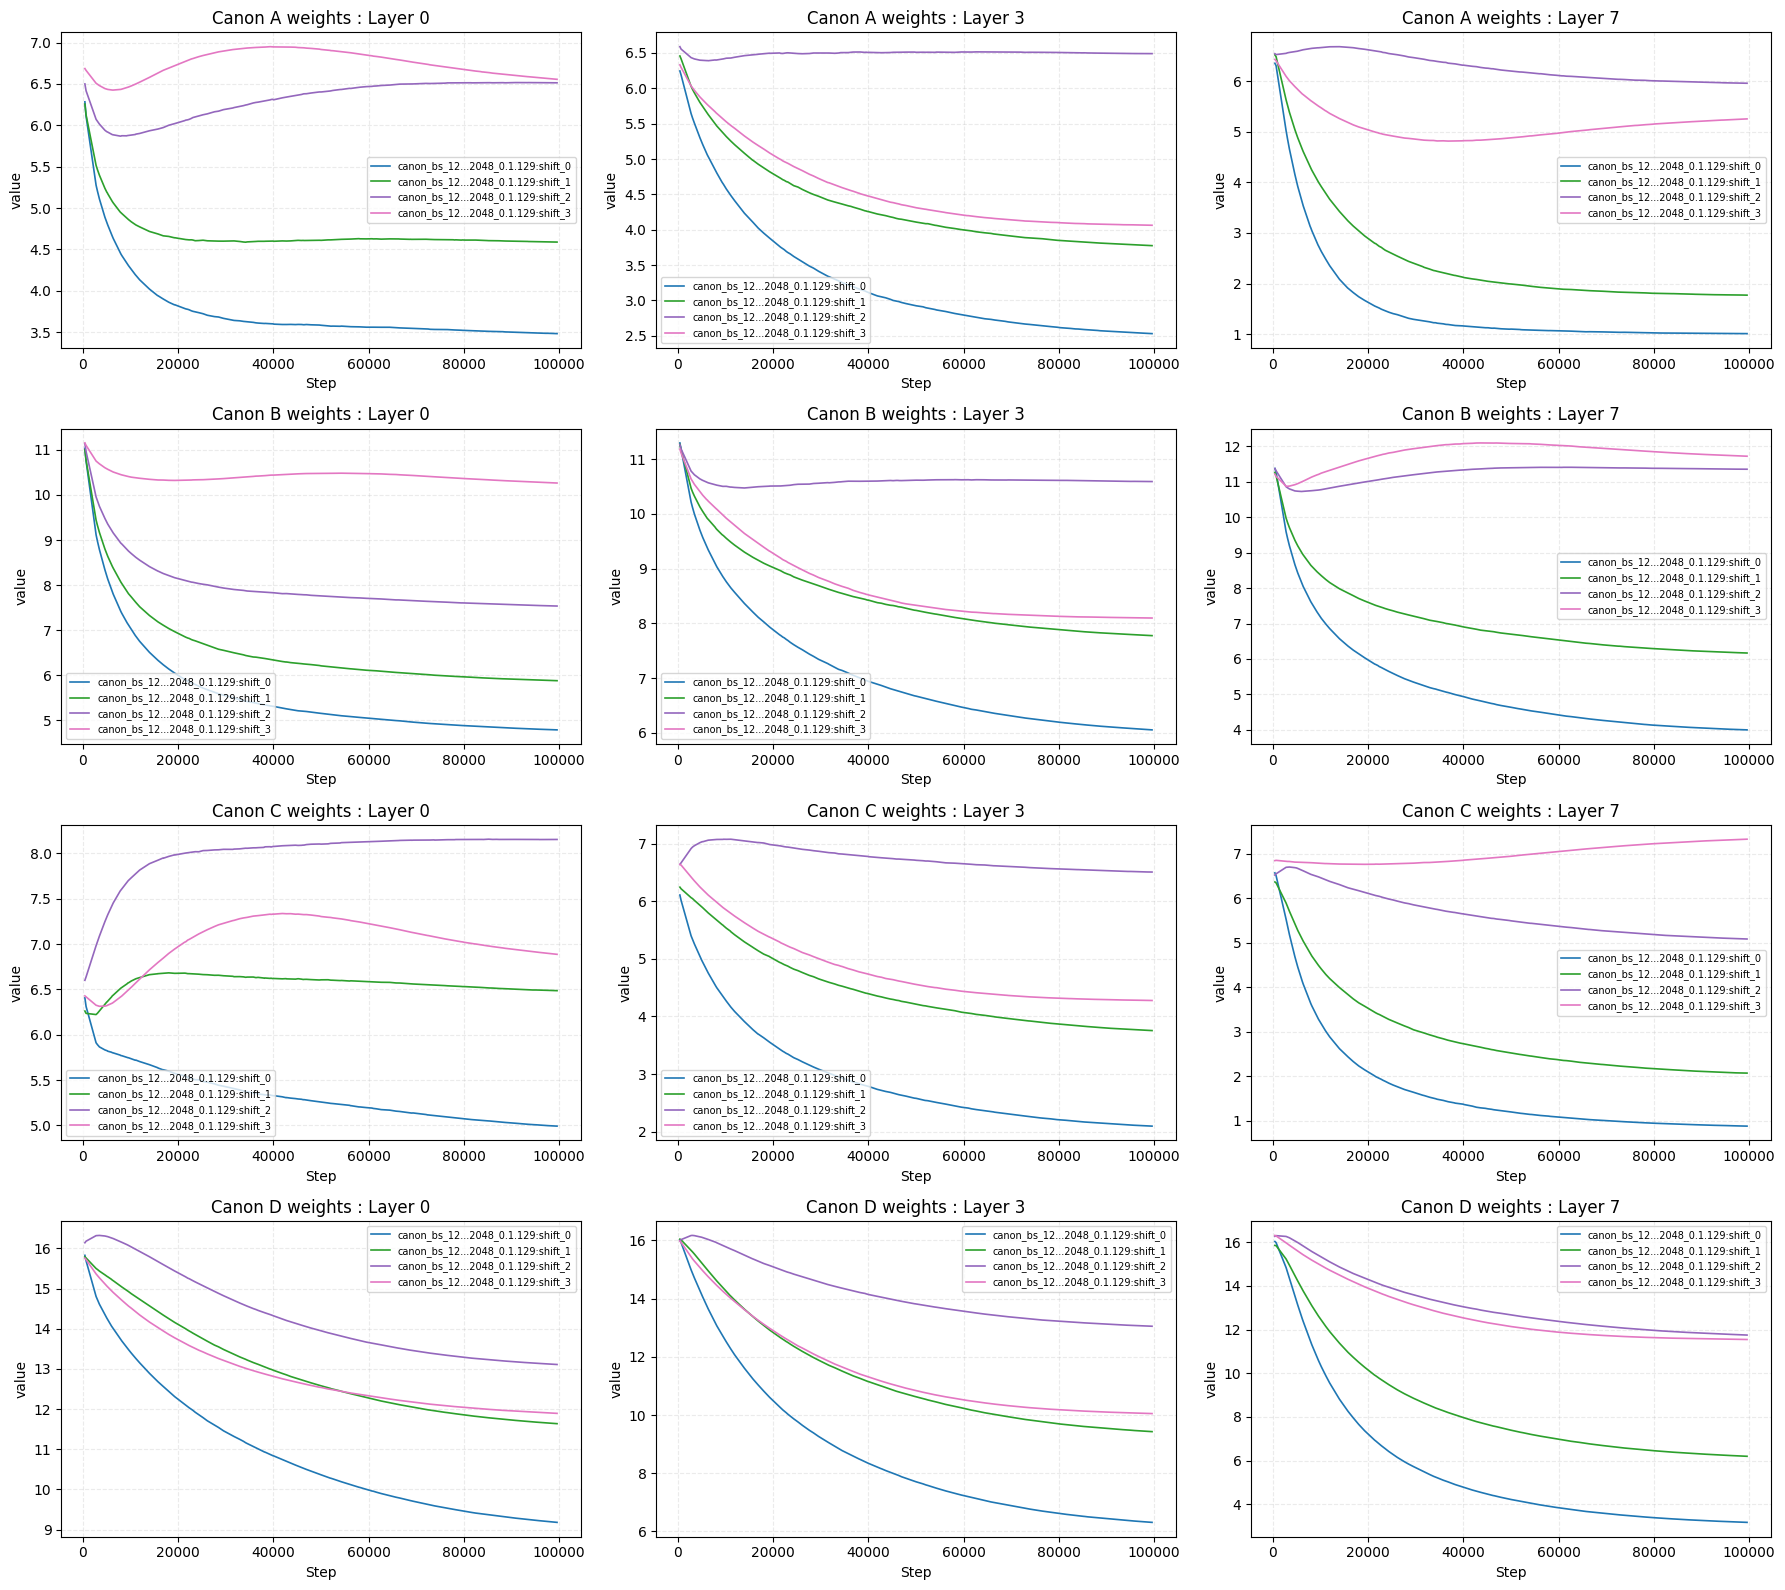

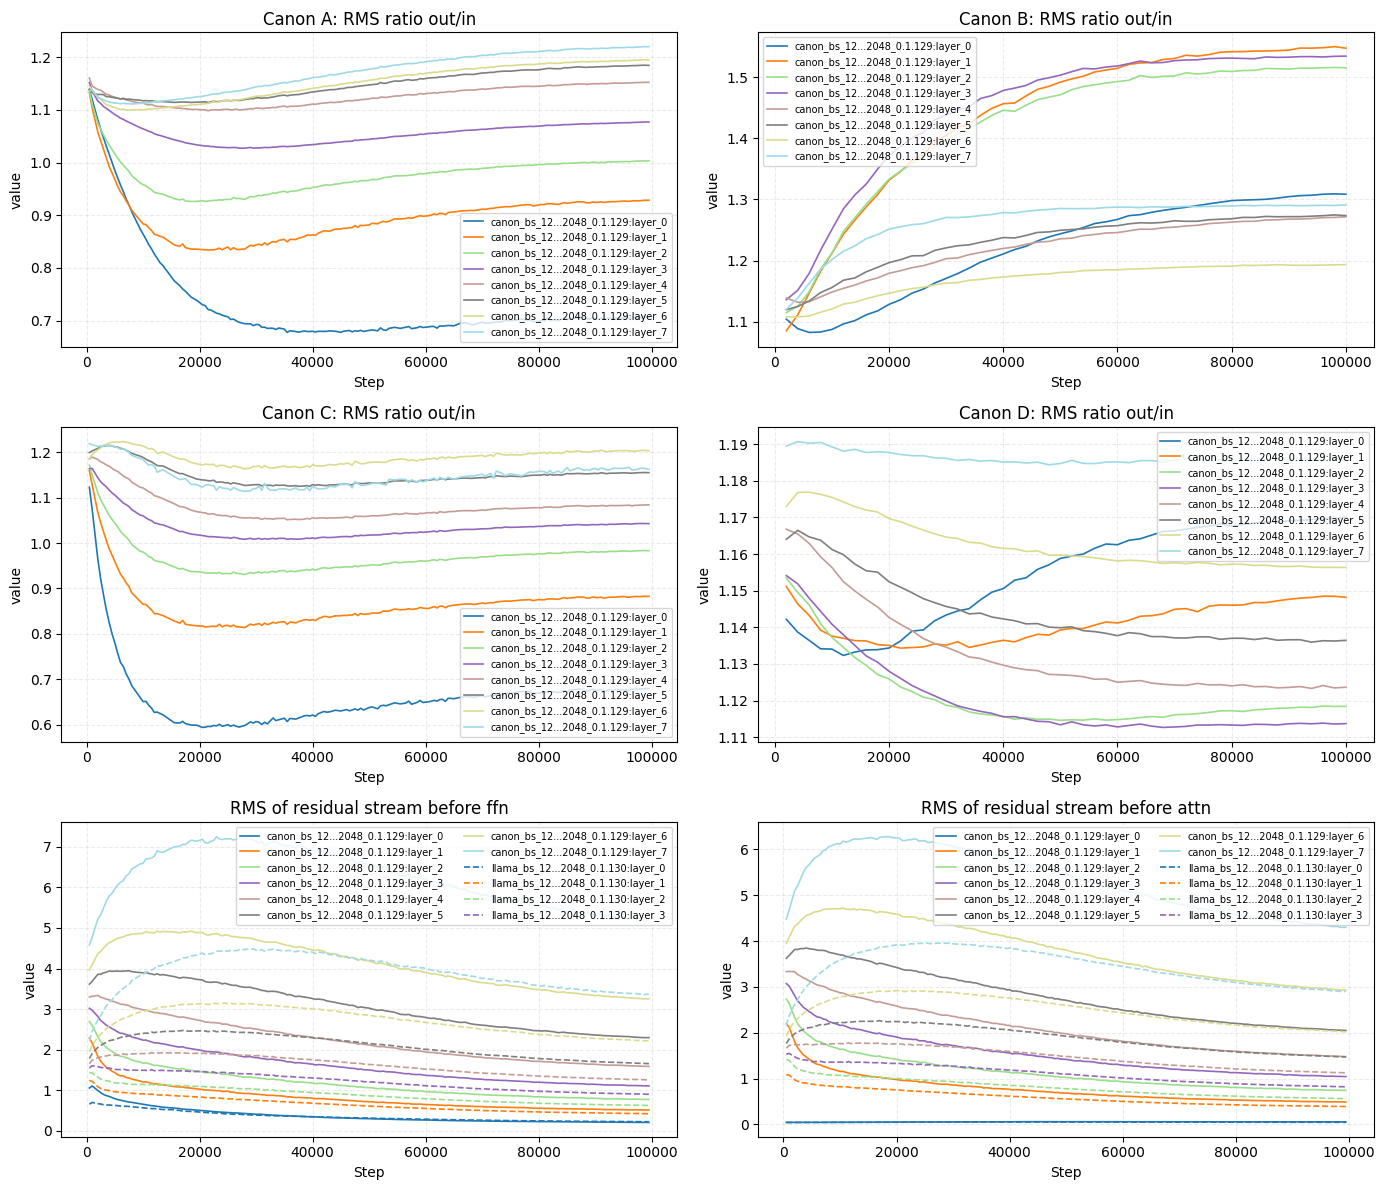

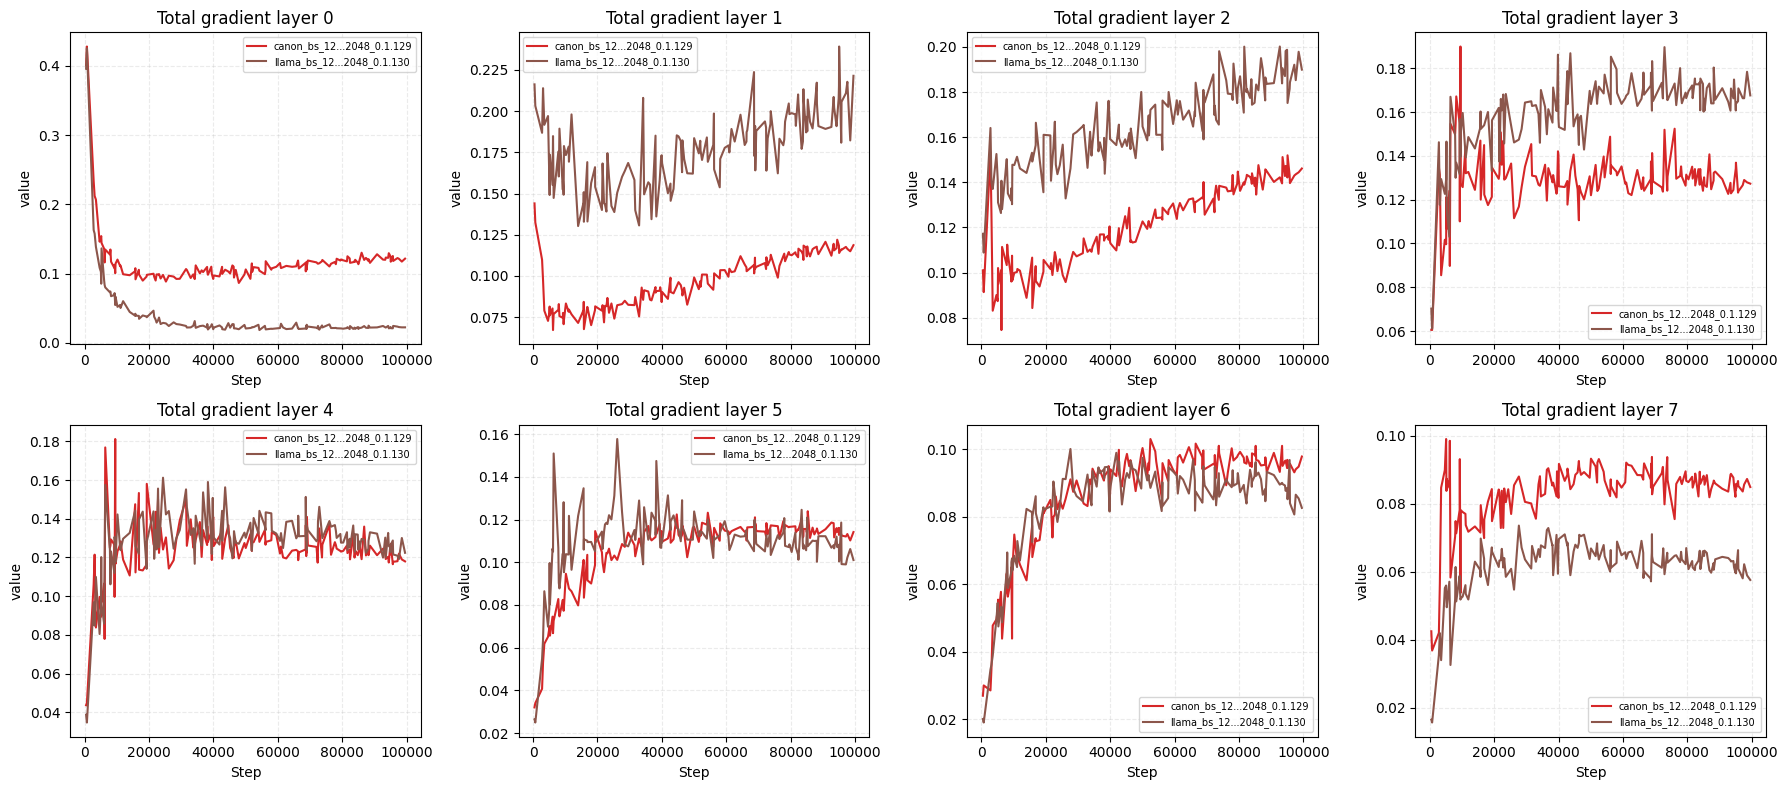

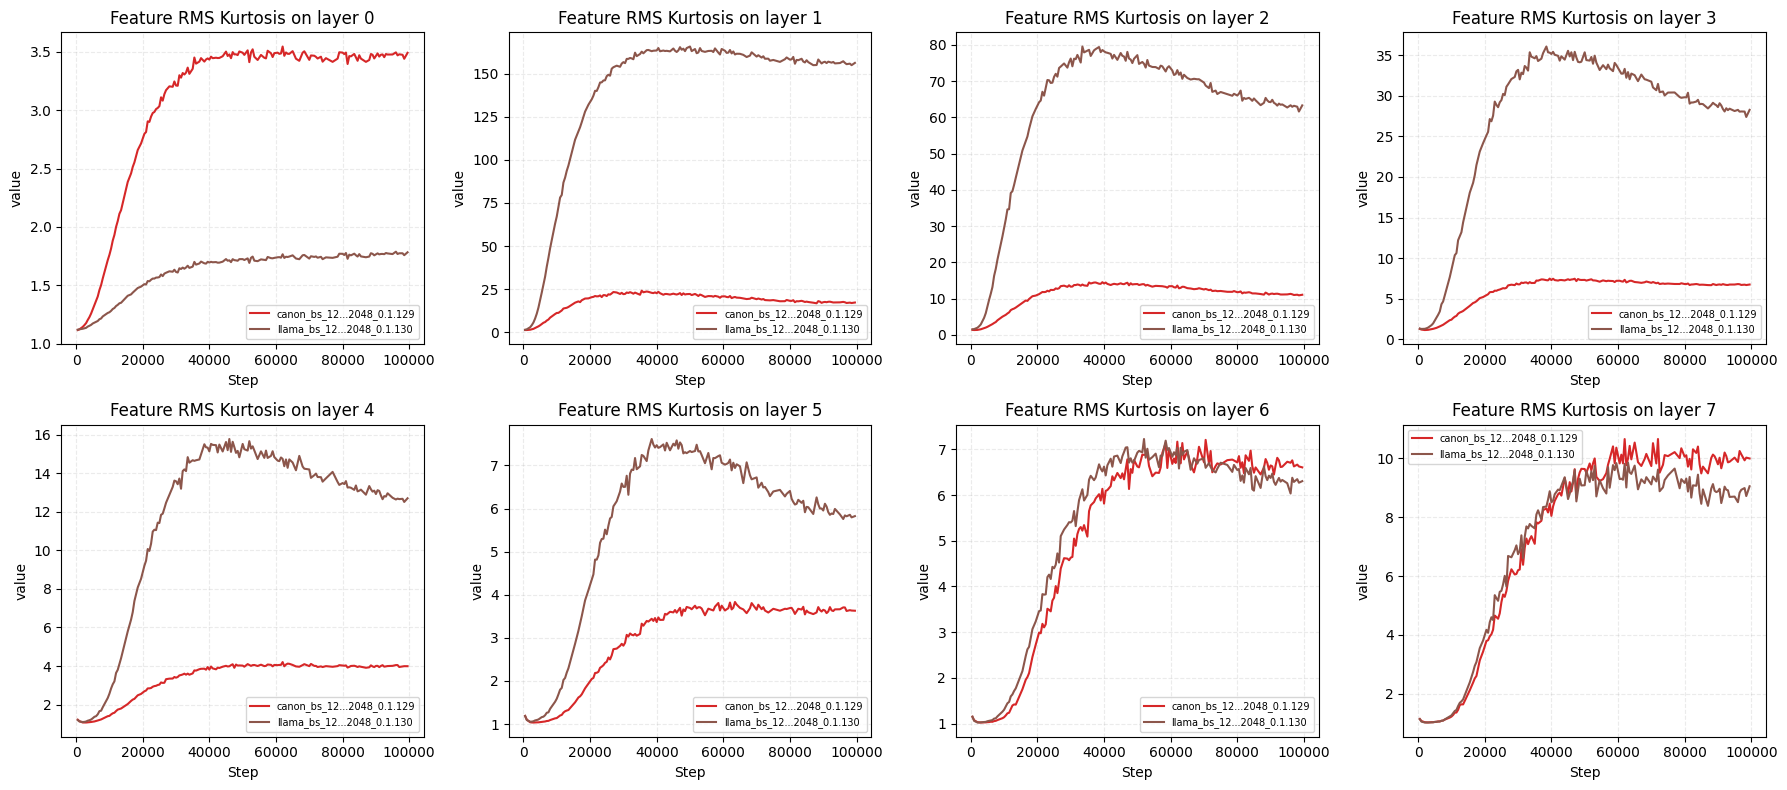

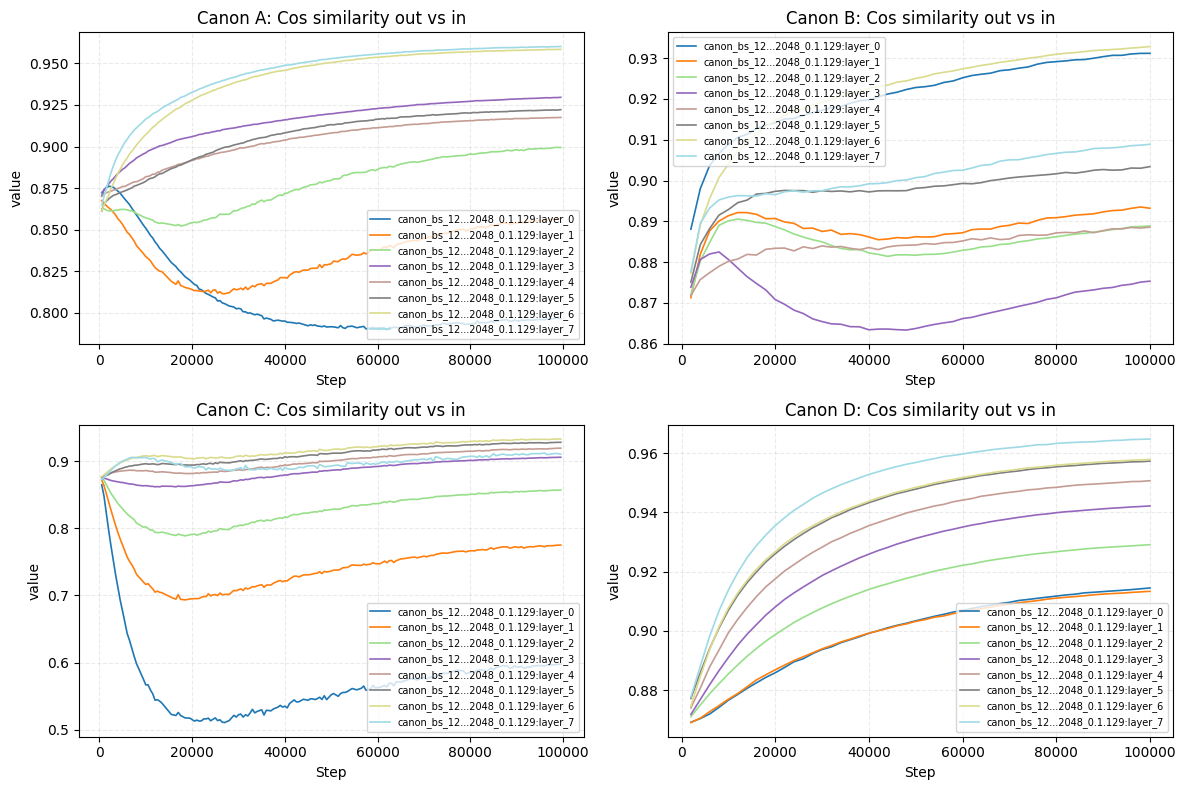

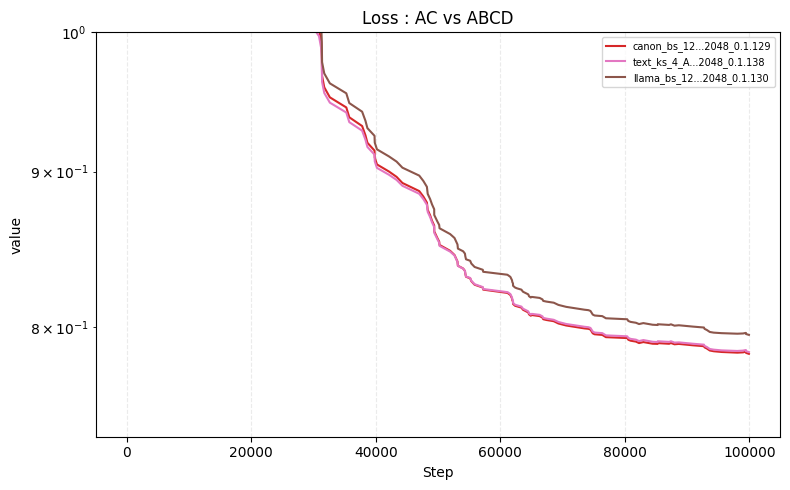

In [19]:
dynamics_observation_runs = [
    #"canon_text_0.1.117", #text_ks_1_default_init_with_residual_trainable_bs_128_seq_len_2048_0.1.117
    #"text_ks_4_const_var_sqr_init_with_residual_trainable_bs_128_seq_len_2048_0.1.147",
    "canon_text_0.1.129", #text_ks_4_default_init_with_residual_trainable_bs_128_seq_len_2048_0.1.129
    #"text_ks_6_const_var_sqr_init_with_residual_trainable_bs_128_seq_len_2048_0.1.148",
    "canon_text_0.1.130" #text_llama_bs_128_seq_len_2048_0.1.130,
]

runs = [runsets_factory.filter_by_run_names(dynamics_observation_runs)] 


canon_weights_layerwise = [
    canon_weight_fixed_layer("A", 0),
    canon_weight_fixed_layer("A", 3),
    canon_weight_fixed_layer("A", 7),
    canon_weight_fixed_layer("B", 0),
    canon_weight_fixed_layer("B", 3),
    canon_weight_fixed_layer("B", 7),
    canon_weight_fixed_layer("C", 0),
    canon_weight_fixed_layer("C", 3),
    canon_weight_fixed_layer("C", 7),
    canon_weight_fixed_layer("D", 0),
    canon_weight_fixed_layer("D", 3),
    canon_weight_fixed_layer("D", 7),
]

canon_weights_fig, canon_weights_path = to_matplotlib(
    canon_weights_layerwise,
    runs,
    num_subplots_h=4,
    num_subplots_w=3,
    h=16,
    w=18,
    output_name="march09_dynamics_canon_weights_layerwise",
    **FAST_PLOT_KWARGS,
)
print(f"Saved: {canon_weights_path}")

report.blocks += [
    wr.H2(text = 'Training dynamics observations'),
    wr.H3(text="Higher canon weights on farther tokens"),
    wr.PanelGrid(
        runsets = runs,
        panels = canon_weights_layerwise,
        hide_run_sets = True
    )
]

### RMS ratio
from plots import canon_rms_ratio, residual_rms, realign_grid

rms_plots = [
    canon_rms_ratio("A"),
    canon_rms_ratio("B"),
    canon_rms_ratio("C"),
    canon_rms_ratio("D"),
    residual_rms("ffn"),
    residual_rms("attn")
]

rms_plots = realign_grid(rms_plots, num_columns = 2, total_w = 25, plot_h = 7)
rms_fig, rms_path = to_matplotlib(
    rms_plots,
    runs,
    num_subplots_h=3,
    num_subplots_w=2,
    h=12,
    w=14,
    output_name="march09_dynamics_rms_ratio_and_residual",
    **FAST_PLOT_KWARGS,
)
print(f"Saved: {rms_path}")

report.blocks += [
    wr.H3(text="Canon upscales representations"),
    wr.P(text="A and C canon upscale later layers more than early ones"),
    wr.PanelGrid(
        runsets = runs,
        panels = rms_plots,
        hide_run_sets = True,
    )
]

### Higher gradients on further layers
from plots import grad_contrib

grad_plots = [
    grad_contrib(layer_idx) for layer_idx in range(0, 8)
]

grad_plots = realign_grid(grad_plots, num_columns = 4, total_w = 25, plot_h = 7)
grad_fig, grad_path = to_matplotlib(
    grad_plots,
    runs,
    num_subplots_h=2,
    num_subplots_w=4,
    h=8,
    w=18,
    output_name="march09_dynamics_grad_contrib",
    **FAST_PLOT_KWARGS,
)
print(f"Saved: {grad_path}")

report.blocks += [
    wr.P(text="And increases gradients on deeper layers"),
    wr.PanelGrid(
        runsets = runs,
        panels = grad_plots,
        hide_run_sets = True,
    )
]

### Outlier features

from plots import outlier_features_kurtosis

outlier_plots = [
    outlier_features_kurtosis(layer_idx) for layer_idx in range(0, 8)
]

outlier_plots = realign_grid(outlier_plots, num_columns = 4, total_w = 25, plot_h = 7)
outlier_fig, outlier_path = to_matplotlib(
    outlier_plots,
    runs,
    num_subplots_h=2,
    num_subplots_w=4,
    h=8,
    w=18,
    output_name="march09_dynamics_outlier_features_kurtosis",
    **FAST_PLOT_KWARGS,
)
print(f"Saved: {outlier_path}")

report.blocks += [
    wr.H3("Much more uniform features"),
    wr.P("Except for layer 0 ..."),
    wr.PanelGrid(
        runsets = runs,
        panels = outlier_plots,
        hide_run_sets = True,
    )
]

### Cos sim

from plots import cos_sim

cos_plots = [
    cos_sim(canon_type) for canon_type in ["A", "B", "C", "D"]
]
cos_plots = realign_grid(cos_plots, num_columns = 2, total_w = 25, plot_h = 7)
cos_fig, cos_path = to_matplotlib(
    cos_plots,
    runs,
    num_subplots_h=2,
    num_subplots_w=2,
    h=8,
    w=12,
    output_name="march09_dynamics_canon_cos_similarity",
    **FAST_PLOT_KWARGS,
)
print(f"Saved: {cos_path}")

report.blocks += [
    wr.H3(text="More mixing on first layers and in canons A, C"),
    wr.PanelGrid(
        runsets = runs,
        panels = cos_plots,
        hide_run_sets = True,
    )
]

# AC vs ABCD

ac_vs_abcd_run_names = [
    #"canon_text_0.1.117", #text_ks_1_default_init_with_residual_trainable_bs_128_seq_len_2048_0.1.117
    "canon_text_0.1.129",
    #"text_ks_6_const_var_sqr_init_with_residual_trainable_bs_128_seq_len_2048_0.1.148",
    "text_ks_4_default_init_with_residual_trainable_bs_128_seq_len_2048_0.1.138", #text_llama_bs_128_seq_len_2048_0.1.130
    "canon_text_0.1.130" #text_llama_bs_128_seq_len_2048_0.1.130,
]

runs = [runsets_factory.filter_by_run_names(ac_vs_abcd_run_names)] 
ac_vs_abcd_plots = [loss_lineplot("AC vs ABCD")]
ac_vs_abcd_fig, ac_vs_abcd_path = to_matplotlib(
    ac_vs_abcd_plots,
    runs,
    num_subplots_h=1,
    num_subplots_w=1,
    h=5,
    w=8,
    output_name="march09_dynamics_loss_ac_vs_abcd",
    **FAST_PLOT_KWARGS,
)
print(f"Saved: {ac_vs_abcd_path}")

report.blocks += [
    wr.P(text="Canon AC is almost as good as ABCD"),
    wr.PanelGrid(
        runsets = runs,
        panels = ac_vs_abcd_plots,
        hide_run_sets = True,
    )
]


march09_dynamics_canon_weights_layerwise: In general higher weights for higher shifts (shift 3 is more important than 2 than 1 etc)

march09_dynamics_rms_ratio_and_residual: showcases ratio of representaiton after canon to input. the representations are getting upscaled and deeper layers (closer to lm head) are getting scaled more

march09_dynamics_grad_contrib: gradient values mid training
baseline: 20 (layer 7) -> 18 -> 16 -> 12 ->10 -> 9 -> 6 (layer 0)
canon: 11 (layer 7) -> 12 -> 12 -> 11 -> 11 -> 9 -> 8 (layer 0)
smoother grads for canon

march09_dynamics_canon_cos_similarity: cosine similarity between canon output and input - the deeper the layer is the higher is similarity

march09_dynamics_loss_ac_vs_abcd: ac and abcd canon are much better than baseline and produce about the same results

In [20]:
report.save();

wandb: Saved report to: https://wandb.ai/kirill456z/physics4llm/reports/Phyics-4-LLM--VmlldzoxNjE0MzE4NA==
